# P5 — Granularity EDA: Half-hourly vs Daily

**Purpose**: establish, with evidence rather than assumption, how much detail is gained or lost between half-hourly and daily resolution for the training data — zero-inflation, distribution shape, week-level texture, and seasonal signal. **This notebook makes no granularity recommendation** — it reports findings for Simon to pick from.

**Scope constraint, strictly enforced throughout**: only `split == "train"` sites are loaded or inspected. Val and test sites are never touched here, even for exploratory purposes — the split exists precisely so no modelling decision (and this notebook's findings will inform one) leaks information from held-out sites.

**Fuel types covered**: the five stratified types (WIND, CCGT, NPSHYD, NUCLEAR, OCGT) plus two of the largest sub-threshold types for contrast (COAL, BIOMASS) — chosen to span the baseload/intermittent spectrum, not because they're evaluation targets themselves.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

INTERIM_DIR = Path("../data/interim")
REF_DIR = Path("../data/reference")

# Fixed colour per fuel type throughout this notebook - never reassigned, never
# cycled, so the same fuel type always reads as the same colour across every plot.
FUEL_COLOURS = {
    "WIND": "#2a78d6",
    "CCGT": "#eb6834",
    "NPSHYD": "#1baf7a",
    "NUCLEAR": "#eda100",
    "OCGT": "#e87ba4",
    "COAL": "#008300",
    "BIOMASS": "#4a3aa7",
}
FUEL_TYPES = list(FUEL_COLOURS.keys())  # stratified five + two sub-threshold for contrast

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

## Load train-only data

Loading the consolidated parquet (which already carries the `split` column baked in from the extraction notebook) and filtering to `split == "train"` immediately, before anything else happens — no val/test row is ever held in memory here. Cross-checked against `site_split_assignment.csv` as the authoritative split source.

In [2]:
# Authoritative split source, checked against the parquet's own split column
split_assignment = pd.read_csv(REF_DIR / "site_split_assignment.csv")
train_keys = set(
    zip(split_assignment.loc[split_assignment["split"] == "train", "dictionary_id"],
        split_assignment.loc[split_assignment["split"] == "train", "fuel_type"])
)

raw = pd.read_parquet(INTERIM_DIR / "site_generation_consolidated.parquet")
assert set(raw["split"].unique()) <= {"train", "val", "test"}

df = raw.loc[raw["split"] == "train"].copy()
del raw  # don't keep the full (incl. val/test) frame around any longer than needed

# Sanity-check the parquet's split column against the CSV, since the brief treats them as equivalent
parquet_train_keys = set(zip(df["dictionary_id"], df["fuel_type"]))
assert parquet_train_keys == train_keys, "parquet split column disagrees with site_split_assignment.csv"

df = df[df["fuel_type"].isin(FUEL_TYPES)].reset_index(drop=True)

# Half-hourly timestamp from settlementDate + settlementPeriod (period 1 = 00:00-00:30)
df["settlementDate"] = pd.to_datetime(df["settlementDate"])
df["timestamp"] = df["settlementDate"] + pd.to_timedelta((df["settlementPeriod"] - 1) * 30, unit="min")

print(f"Train-only rows: {len(df):,}")
print(f"Train sites (site_fuel_id) by fuel type covered here:")
print(df.groupby("fuel_type")["site_fuel_id"].nunique().reindex(FUEL_TYPES))

Train-only rows: 17,145,344
Train sites (site_fuel_id) by fuel type covered here:


fuel_type
WIND       80
CCGT       26
NPSHYD      9
NUCLEAR     6
OCGT        8
COAL        5
BIOMASS     4
Name: site_fuel_id, dtype: int64


## Step 1 — Half-hourly zero-inflation

Registered capacity isn't in this dataset, so there's no true capacity factor to compute. **Proxy, not ground truth**: each site's own observed maximum absolute output stands in for its scale. "Near-zero" is defined as `|quantity| <= threshold × site's observed max` — absolute value because a handful of sites show small negative excursions (auxiliary/house load drawn when not generating), which are just as much "near-zero output" as a small positive value.

The threshold itself is a judgement call, so it's swept rather than picked silently: **1%, 5%, 10%** of each site's own observed max, reported side by side.

In [3]:
NEAR_ZERO_THRESHOLDS = [0.01, 0.05, 0.10]

# Each site's own observed max |output| - the proxy scale, computed once and reused
site_max = df.groupby("site_fuel_id")["quantity"].apply(lambda s: s.abs().max())
df["site_max_abs"] = df["site_fuel_id"].map(site_max)
df["abs_quantity"] = df["quantity"].abs()


def near_zero_proportion(frame, thresholds=NEAR_ZERO_THRESHOLDS, value_col="abs_quantity", scale_col="site_max_abs"):
    """Pooled proportion of half-hourly (or daily) periods at or below each threshold,
    across all periods for all sites of a fuel type - not averaged per-site first."""
    out = {}
    for t in thresholds:
        out[f"<= {t:.0%} of site max"] = (frame[value_col] <= t * frame[scale_col]).mean()
    return pd.Series(out)


hh_zero_inflation = df.groupby("fuel_type").apply(near_zero_proportion, include_groups=False).reindex(FUEL_TYPES)
print("Half-hourly near-zero proportion, pooled across all training-site periods per fuel type:")
print(hh_zero_inflation.round(4))
hh_zero_inflation.style.format("{:.1%}")

Half-hourly near-zero proportion, pooled across all training-site periods per fuel type:
           <= 1% of site max  <= 5% of site max  <= 10% of site max
fuel_type                                                          
WIND                  0.1987             0.3159              0.4134
CCGT                  0.4416             0.4707              0.4846
NPSHYD                0.3960             0.4406              0.4721
NUCLEAR               0.5245             0.5313              0.5315
OCGT                  0.9057             0.9976              0.9978
COAL                  0.8703             0.8733              0.8759
BIOMASS               0.1664             0.1963              0.1978


,<= 1% of site max,<= 5% of site max,<= 10% of site max
fuel_type,,,
WIND,19.9%,31.6%,41.3%
CCGT,44.2%,47.1%,48.5%
NPSHYD,39.6%,44.1%,47.2%
NUCLEAR,52.4%,53.1%,53.2%
OCGT,90.6%,99.8%,99.8%
COAL,87.0%,87.3%,87.6%
BIOMASS,16.6%,19.6%,19.8%


**NUCLEAR's 52% pooled figure is surprisingly high for a baseload fuel type and is worth breaking down per site before trusting it** — pooled statistics can hide site-level heterogeneity that changes the interpretation entirely.

In [4]:
nuclear_by_site = (
    df.loc[df["fuel_type"] == "NUCLEAR"]
    .groupby("site_fuel_id")
    .apply(lambda s: pd.Series({
        "mean_MW": s["quantity"].mean(),
        "observed_max_MW": s["site_max_abs"].iloc[0],
        "pct_near_zero_5pct": (s["abs_quantity"] <= 0.05 * s["site_max_abs"]).mean(),
        "n_periods": len(s),
    }), include_groups=False)
)
print("NUCLEAR training sites, individually:")
print(nuclear_by_site.round(3))

dead_sites = nuclear_by_site.index[nuclear_by_site["pct_near_zero_5pct"] > 0.99].tolist()
print(f"\n{len(dead_sites)} of {len(nuclear_by_site)} NUCLEAR training sites are >99% near-zero across their ENTIRE record: {dead_sites}")
print("These read as non-operating BMUs registered under the NUCLEAR fuel type, not genuine baseload generation with occasional outages -")
print("the same 'registered but not delivering' pattern as BAGE-1 in the exploration notebook, just not caught by the manifest (the API")
print("does return values here, they're just consistently ~0, so no chunk was ever logged as zero-rows-returned).")

NUCLEAR training sites, individually:
               mean_MW  observed_max_MW  pct_near_zero_5pct  n_periods
site_fuel_id                                                          
10128_NUCLEAR    0.000           24.958               1.000   130808.0
10131_NUCLEAR  816.369         1189.232               0.012   130808.0
10133_NUCLEAR  134.474          511.324               0.655   130808.0
10134_NUCLEAR  203.791          516.740               0.464    51267.0
10136_NUCLEAR  486.638          606.170               0.151   130808.0
10139_NUCLEAR    0.000            0.000               1.000    93171.0

2 of 6 NUCLEAR training sites are >99% near-zero across their ENTIRE record: ['10128_NUCLEAR', '10139_NUCLEAR']
These read as non-operating BMUs registered under the NUCLEAR fuel type, not genuine baseload generation with occasional outages -
the same 'registered but not delivering' pattern as BAGE-1 in the exploration notebook, just not caught by the manifest (the API
does return values he

## Step 2 — Half-hourly output distribution shape

The percentages above are a single summary; the actual *shape* of each fuel type's output distribution shows the baseload/intermittent contrast directly. Each site's output is normalised by its own observed max (`quantity / site_max_abs`) so fuel types with very different absolute scales (nuclear ~1,000 MW vs small hydro ~tens of MW) sit on the same 0-1 axis and are genuinely comparable.

Plotted from a random sample of the pooled half-hourly records per fuel type (up to 200,000 points each) — for rendering speed only; the Step 1 percentages above use the full data, not this sample.

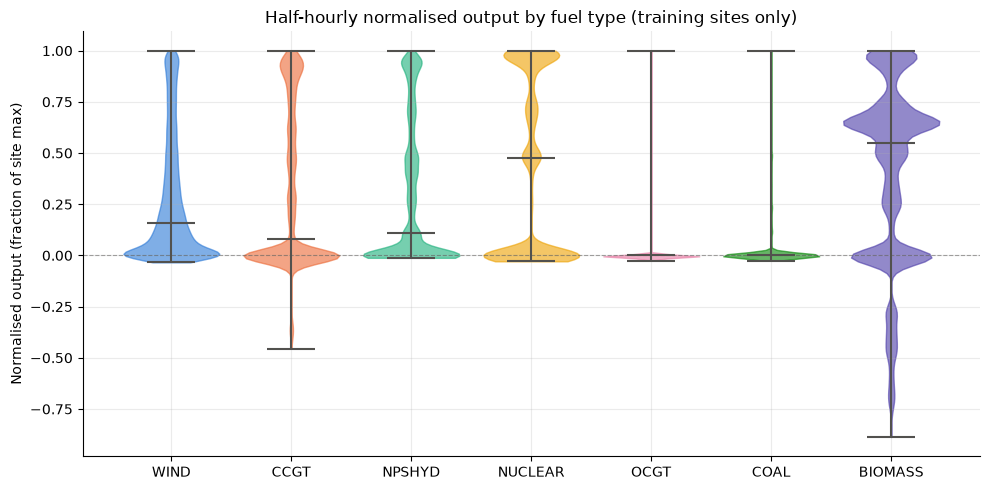

In [5]:
df["normalised"] = df["quantity"] / df["site_max_abs"]

RNG_SEED = 42
SAMPLE_PER_FUEL = 200_000


def sampled_distributions(frame, value_col, fuel_types=FUEL_TYPES, n=SAMPLE_PER_FUEL, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    samples = []
    for ft in fuel_types:
        vals = frame.loc[frame["fuel_type"] == ft, value_col].dropna().to_numpy()
        if len(vals) > n:
            vals = rng.choice(vals, size=n, replace=False)
        samples.append(vals)
    return samples


def plot_violin(frame, value_col, title, ax=None, ylabel="Normalised output (fraction of site max)"):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))
    samples = sampled_distributions(frame, value_col)
    parts = ax.violinplot(samples, showmedians=True, widths=0.8)
    for i, body in enumerate(parts["bodies"]):
        colour = FUEL_COLOURS[FUEL_TYPES[i]]
        body.set_facecolor(colour)
        body.set_edgecolor(colour)
        body.set_alpha(0.6)
    for key in ("cbars", "cmins", "cmaxes", "cmedians"):
        parts[key].set_color("#52514e")
    ax.set_xticks(range(1, len(FUEL_TYPES) + 1))
    ax.set_xticklabels(FUEL_TYPES)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.axhline(0, color="#52514e", linewidth=0.8, linestyle="--", alpha=0.5)
    return ax


plot_violin(df, "normalised", "Half-hourly normalised output by fuel type (training sites only)")
plt.tight_layout()
plt.show()

## Step 3 — Daily resolution: does aggregation wash out the zero-inflation?

Resampling each training site to a daily mean (mean of that day's up-to-48 half-hourly periods), then repeating exactly the same near-zero and distribution analysis. **Same site scale (half-hourly observed max) used for both resolutions** — this keeps the "near-zero relative to what?" reference point consistent, so the comparison is genuinely about what daily averaging does to the signal, not an artefact of rescaling.

In [6]:
daily = (
    df.groupby(["site_fuel_id", "fuel_type", "settlementDate"], as_index=False)["quantity"]
    .mean()
    .rename(columns={"settlementDate": "date"})
)
daily["site_max_abs"] = daily["site_fuel_id"].map(site_max)  # same half-hourly-derived scale as Step 1
daily["abs_quantity"] = daily["quantity"].abs()
daily["normalised"] = daily["quantity"] / daily["site_max_abs"]

daily_zero_inflation = daily.groupby("fuel_type").apply(near_zero_proportion, include_groups=False).reindex(FUEL_TYPES)

print(f"Half-hourly rows: {len(df):,}  ->  Daily rows: {len(daily):,}")
print()
print("Daily near-zero proportion, pooled across all training-site days per fuel type:")
print(daily_zero_inflation.round(4))

Half-hourly rows: 17,145,344  ->  Daily rows: 358,217

Daily near-zero proportion, pooled across all training-site days per fuel type:
           <= 1% of site max  <= 5% of site max  <= 10% of site max
fuel_type                                                          
WIND                  0.0797             0.1944              0.3086
CCGT                  0.3405             0.3753              0.4081
NPSHYD                0.1586             0.2127              0.2810
NUCLEAR               0.5238             0.5306              0.5309
OCGT                  0.8905             0.9923              0.9969
COAL                  0.8222             0.8415              0.8663
BIOMASS               0.1619             0.1897              0.1930


In [7]:
# Side-by-side comparison at the 5% threshold (the middle of the swept range) for readability;
# the full sweep for both resolutions is in the two tables above
comparison = pd.DataFrame({
    "half-hourly": hh_zero_inflation["<= 5% of site max"],
    "daily": daily_zero_inflation["<= 5% of site max"],
})
comparison["absolute change (pp)"] = (comparison["daily"] - comparison["half-hourly"]) * 100
comparison["relative change"] = (comparison["daily"] / comparison["half-hourly"] - 1)

print("Near-zero proportion (<=5% of site max threshold): half-hourly vs daily")
comparison.style.format({
    "half-hourly": "{:.1%}", "daily": "{:.1%}",
    "absolute change (pp)": "{:+.1f}", "relative change": "{:+.1%}",
})

Near-zero proportion (<=5% of site max threshold): half-hourly vs daily


,half-hourly,daily,absolute change (pp),relative change
fuel_type,,,,
WIND,31.6%,19.4%,-12.1,-38.5%
CCGT,47.1%,37.5%,-9.5,-20.3%
NPSHYD,44.1%,21.3%,-22.8,-51.7%
NUCLEAR,53.1%,53.1%,-0.1,-0.1%
OCGT,99.8%,99.2%,-0.5,-0.5%
COAL,87.3%,84.2%,-3.2,-3.6%
BIOMASS,19.6%,19.0%,-0.7,-3.4%


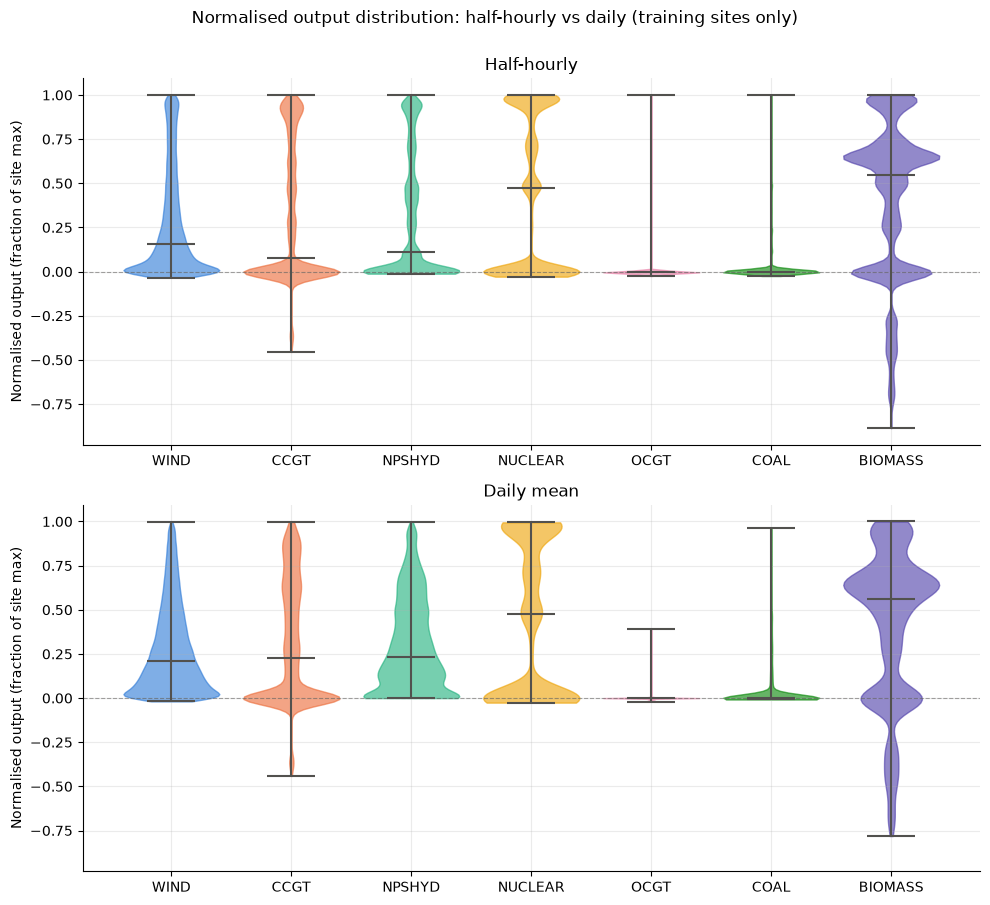

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharey=True)
plot_violin(df, "normalised", "Half-hourly", ax=axes[0])
plot_violin(daily, "normalised", "Daily mean", ax=axes[1])
fig.suptitle("Normalised output distribution: half-hourly vs daily (training sites only)", y=1.0)
plt.tight_layout()
plt.show()

## Step 4 — Week-level detail: half-hourly vs daily, for real sites

Summary statistics can hide what's actually being gained or lost. One representative training site each for WIND, NUCLEAR and OCGT, plotted at half-hourly resolution next to that same week's daily mean.

**Site selection, revised after an initial mistake**: picking "the site with the most complete record" turned out to select two effectively-dead BMUs for NUCLEAR and OCGT (registered under those fuel types but reading ~0 for their entire multi-year history — the same "registered but not delivering" pattern as `BAGE-1` from the exploration notebook, just not caught by the manifest since the API still returns values here, they're just consistently zero). Site selection is now by **highest observed maximum output** instead, which picks a genuinely active generator. **Week selection** is then the single most active week in that site's own record (highest total absolute output) — not the same calendar week forced across all three, since the point here is to show real peak/trough detail, not to force a comparison across an arbitrary shared date that might land on a flat period for one of them.

In [9]:
REPRESENTATIVE_FUEL_TYPES = ["WIND", "NUCLEAR", "OCGT"]

representative_sites = {}
representative_weeks = {}
for ft in REPRESENTATIVE_FUEL_TYPES:
    ft_df = df.loc[df["fuel_type"] == ft]
    site = ft_df.groupby("site_fuel_id")["site_max_abs"].first().idxmax()  # largest real capacity, not just longest record
    representative_sites[ft] = site

    site_df = ft_df.loc[ft_df["site_fuel_id"] == site].copy()
    site_df["week_start"] = site_df["timestamp"].dt.to_period("W-SUN").dt.start_time
    weekly_activity = site_df.groupby("week_start")["abs_quantity"].sum()
    full_weeks = site_df.groupby("week_start").size()
    weekly_activity = weekly_activity[full_weeks >= 336]  # only consider genuinely complete weeks
    representative_weeks[ft] = weekly_activity.idxmax()

print("Representative training site and its most active complete week, per fuel type:")
for ft in REPRESENTATIVE_FUEL_TYPES:
    site = representative_sites[ft]
    week = representative_weeks[ft]
    obs_max = df.loc[df["site_fuel_id"] == site, "site_max_abs"].iloc[0]
    print(f"  {ft:8s} -> {site:16s} (observed max {obs_max:7.1f} MW) | week of {week.date()}")

Representative training site and its most active complete week, per fuel type:
  WIND     -> 10242_WIND       (observed max   721.0 MW) | week of 2020-02-17
  NUCLEAR  -> 10131_NUCLEAR    (observed max  1189.2 MW) | week of 2024-10-28
  OCGT     -> 10097_OCGT       (observed max    70.3 MW) | week of 2022-08-22


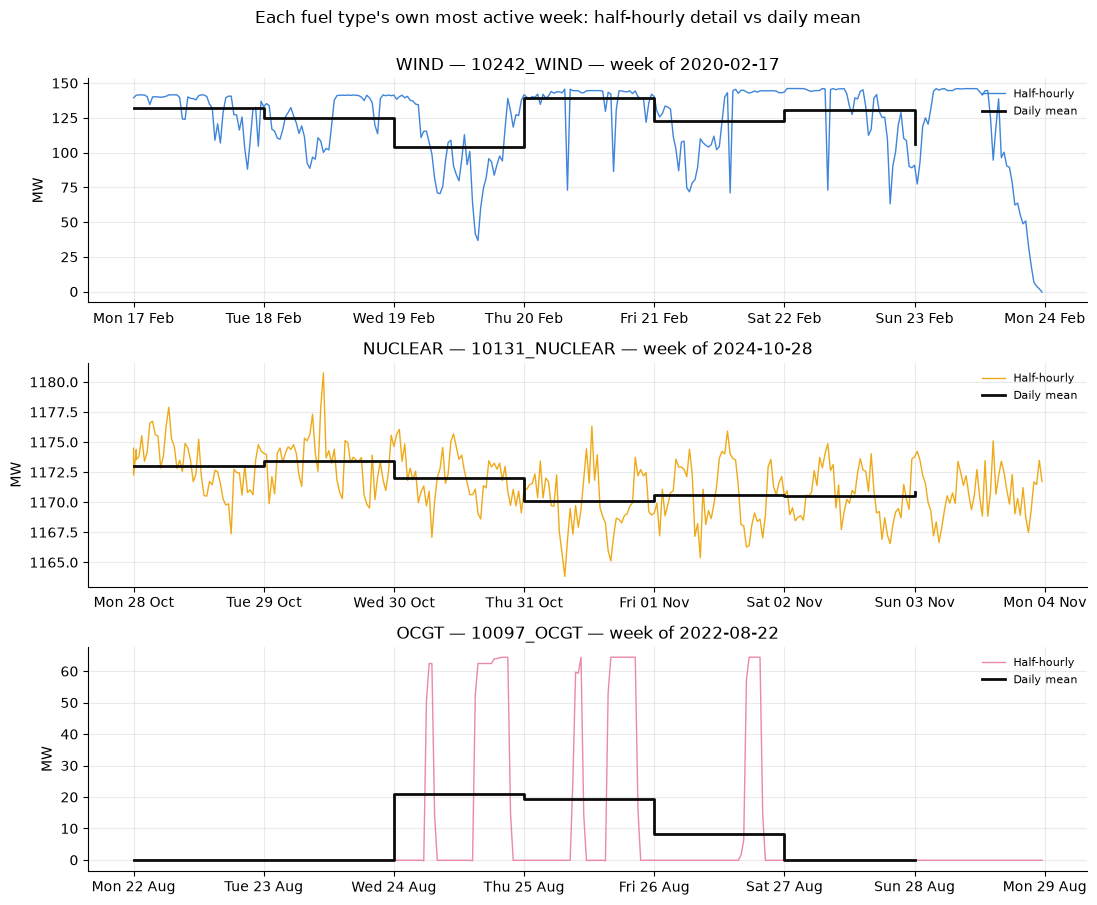

In [10]:
fig, axes = plt.subplots(len(REPRESENTATIVE_FUEL_TYPES), 1, figsize=(11, 9), sharex=False)

for ax, ft in zip(axes, REPRESENTATIVE_FUEL_TYPES):
    site = representative_sites[ft]
    week_start = representative_weeks[ft]
    week_end = week_start + pd.Timedelta(days=7)
    colour = FUEL_COLOURS[ft]

    hh_week = df.loc[(df["site_fuel_id"] == site) & df["timestamp"].between(week_start, week_end, inclusive="left")].sort_values("timestamp")
    daily_week = daily.loc[(daily["site_fuel_id"] == site) & daily["date"].between(week_start, week_end, inclusive="left")].sort_values("date")

    ax.plot(hh_week["timestamp"], hh_week["quantity"], color=colour, linewidth=1, alpha=0.9, label="Half-hourly")
    ax.step(daily_week["date"], daily_week["quantity"], where="post", color="#0b0b0b", linewidth=2, label="Daily mean")

    ax.set_title(f"{ft} \u2014 {site} \u2014 week of {week_start.date()}")
    ax.set_ylabel("MW")
    ax.legend(loc="upper right", frameon=False, fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))

fig.suptitle("Each fuel type's own most active week: half-hourly detail vs daily mean", y=1.0)
plt.tight_layout()
plt.show()

## Step 5 — Seasonal check: does daily resolution still show a clean cycle?

Monthly mean normalised output per fuel type, computed two ways: directly from the half-hourly data, and from the daily means built in Step 3. If daily resolution is losing seasonal texture, these two lines should visibly diverge; if daily resolution is fine for "pick up general cycles," they should sit on top of each other.

Largest monthly difference between the two computation paths (any fuel type, any month): 0.00917


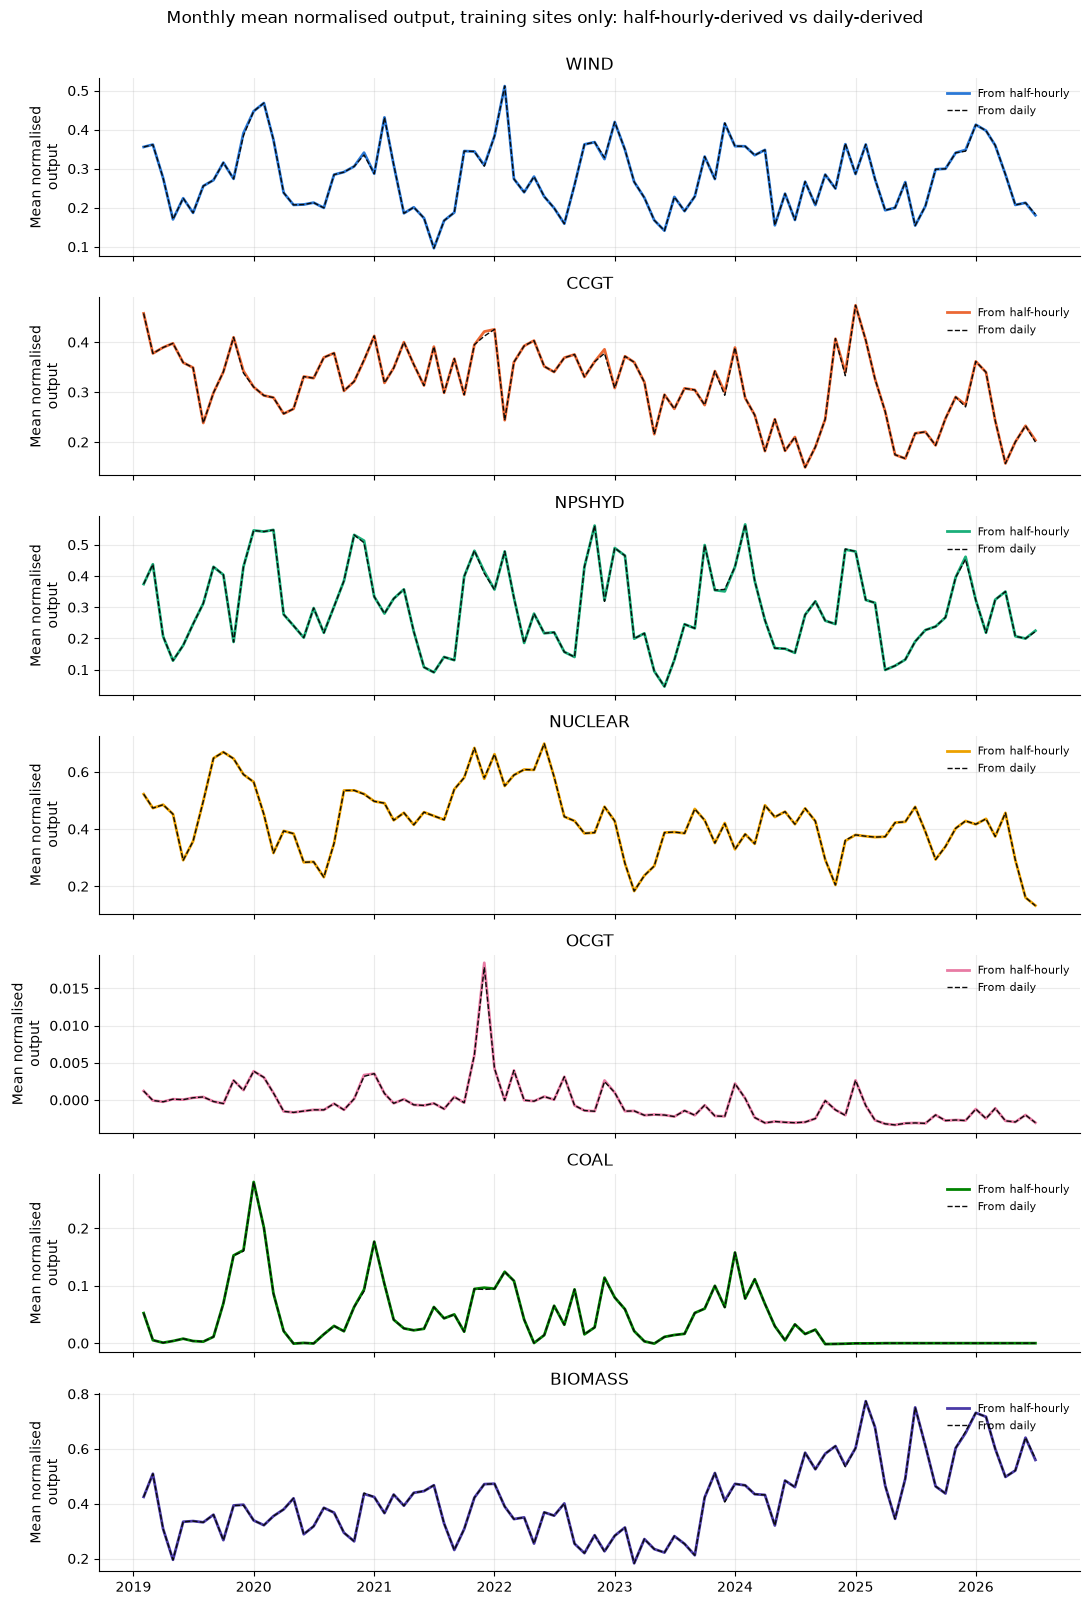

In [11]:
df["month"] = df["timestamp"].dt.to_period("M")
daily["month"] = daily["date"].dt.to_period("M")

monthly_from_hh = df.groupby(["fuel_type", "month"])["normalised"].mean().rename("from_half_hourly")
monthly_from_daily = daily.groupby(["fuel_type", "month"])["normalised"].mean().rename("from_daily")
monthly = pd.concat([monthly_from_hh, monthly_from_daily], axis=1).reset_index()
monthly["month_ts"] = monthly["month"].dt.to_timestamp()

max_abs_diff = (monthly["from_half_hourly"] - monthly["from_daily"]).abs().max()
print(f"Largest monthly difference between the two computation paths (any fuel type, any month): {max_abs_diff:.5f}")

fig, axes = plt.subplots(len(FUEL_TYPES), 1, figsize=(11, 16), sharex=True)
for ax, ft in zip(axes, FUEL_TYPES):
    sub = monthly.loc[monthly["fuel_type"] == ft].sort_values("month_ts")
    colour = FUEL_COLOURS[ft]
    ax.plot(sub["month_ts"], sub["from_half_hourly"], color=colour, linewidth=2, label="From half-hourly")
    ax.plot(sub["month_ts"], sub["from_daily"], color="#0b0b0b", linewidth=1, linestyle="--", label="From daily")
    ax.set_title(ft)
    ax.set_ylabel("Mean normalised\noutput")
    ax.legend(loc="upper right", frameon=False, fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Monthly mean normalised output, training sites only: half-hourly-derived vs daily-derived", y=1.0)
plt.tight_layout()
plt.show()

## Step 6 — Findings summary

**No recommendation is made here** — this is a report of what the data shows, for Simon to weigh in choosing a granularity.

### How zero-inflated is each fuel type, and does daily aggregation wash it out?

At the 5% threshold (half-hourly -> daily, training sites only):

| Fuel type | Half-hourly | Daily | Persists at daily? |
|---|---|---|---|
| OCGT | 99.8% | 99.2% | **Yes, almost unchanged** |
| COAL | 87.3% | 84.2% | Yes, mostly unchanged |
| NUCLEAR | 53.1% | 53.1% | **Yes, unchanged** (see caveat below) |
| CCGT | 47.1% | 37.5% | Partially washed out |
| NPSHYD | 44.1% | 21.3% | Substantially washed out |
| WIND | 31.6% | 19.4% | Substantially washed out |
| BIOMASS | 19.6% | 19.0% | Yes, unchanged |

**The zero-inflation does *not* uniformly wash out at daily resolution.** For OCGT, COAL, NUCLEAR and BIOMASS, daily aggregation barely moves the near-zero proportion at all — because their zero periods tend to be long (multi-day outages, days-long idle stretches), not brief intraday dips that averaging can smooth over. For WIND, NPSHYD and CCGT, daily aggregation meaningfully reduces the near-zero share, because their zero readings are often just a few low-wind or low-flow half-hours within an otherwise-generating day.

Threshold sensitivity (1% -> 10% of site max, half-hourly): WIND (20%->41%) and NPSHYD (40%->47%) shift the most, consistent with gradual ramping through low-output levels; OCGT, COAL, NUCLEAR and BIOMASS barely move between thresholds, consistent with a genuinely bimodal on/off pattern rather than gradual ramping.

**Data-quality finding, not a resolution effect**: NUCLEAR's high pooled figure is significantly inflated by 2 of its 6 training sites (`10128_NUCLEAR`, `10139_NUCLEAR`) reading at or near exactly zero for their *entire* multi-year record — the same "registered but not delivering" pattern as `BAGE-1` from the exploration notebook, just not caught by the manifest since the API still returns values, they're just consistently ~0. The other 4 NUCLEAR sites show genuine baseload behaviour (1.2%-65.5% near-zero, consistent with real operating patterns and refuelling outages).

### Distribution shape (Step 2)

The violin plots show the baseload/intermittent contrast directly: NUCLEAR and BIOMASS concentrate near full output with a separate cluster at zero (maintenance/dead-site outages, not gradual ramping); WIND and NPSHYD spread continuously across the full range, skewed toward low output; OCGT and COAL show the sharpest "off, or nearly full" bimodal shape of all seven, with almost no middle ground. This holds at both half-hourly and daily resolution — the shapes barely change between the two panels.

### What's visibly lost/kept at week level (Step 4)

Three genuinely active representative sites (picked by observed capacity, not "most complete record" — an earlier version of this analysis accidentally picked two dead sites for NUCLEAR and OCGT before that was caught and fixed):

- **NUCLEAR** (`10131_NUCLEAR`): half-hourly output stays within a narrow ~15 MW band around 1,170 MW all week. The daily mean line is almost indistinguishable from the half-hourly trace — **minimal detail lost** for a healthy baseload nuclear site.
- **WIND** (`10242_WIND`): daily mean captures the overall multi-day rise/fall trend, but **misses substantial intraday swings** — troughs dropping to a third of the daily average are invisible in the daily step line.
- **OCGT** (`10097_OCGT`): the most dramatic case. The site sits at literal zero for most of the week, with four sharp spikes to ~60-65 MW lasting only a few hours each. The daily mean doesn't just lose detail here — **it actively misrepresents the operating pattern**, showing a smooth-looking ramp from 0 up to ~20 MW and back down over several days that resembles nothing about how the plant actually runs (off, then briefly at full output, then off again).

### Seasonal signal (Step 5)

Monthly mean normalised output computed from half-hourly data and from daily-resampled data are **effectively identical** — largest absolute difference across all seven fuel types and every month in the dataset is 0.9 percentage points. Daily resolution fully preserves the mean-based monthly/seasonal signal, and clear real patterns are visible in it: WIND's winter peak / summer trough, NPSHYD's rainfall-driven seasonality, COAL's decline to zero by 2025 (matching the UK coal phase-out), and an isolated OCGT spike in August 2022 that lines up with the specific active week found independently in Step 4.